# Embedded ML - Lab 1.2: Model Compression

In this lab you are asked to create a compressed verion of an ANNs model. You are not allowed to use ML libraries such as SciKit-learn, PyTorch or TensorFlow, but you are allowed to use standard libraries such as math, numpy and matplotlib if needed. You are given some code but you are expected to write some more and be able to explain and modify everything. This lab is essential for you to grasp the details of some of the most important techniques for compressing or making ML models more efficient: quantization and pruning.

### Learning outcomes


* Explain the basic concepts of compression in ANNs
* Apply range tuning and centering when doing quantization
* Calculate and analyze the impact of quantization and pruning on memory and computing

### Naive quantization
Quantization means reducing the precission of model parameters and mainly targets weights, since they represent the most volumne of memory and processing in ANNs.

Take the code from the last part of Lab 1.1 (MNIST model) and add methods to export and import weights to and from a binary file, making sure both processes work with your code in such a way that you don't have to train every time you want to run inference, but insted, the weights are loaded into the model when needed. Investigate which serialization/desarialization options exist in Python and choose one that you understand.

Then, create two additional inference methods: FP16 and INT8. The FP16 method should treat all computations in the network involving the weights, as 16-bit floating-point. The INT8 method should work with 8-bit integers instead. In both cases, use the native datatype conversion methods. Investigate the NumPy methods available to enforce the desired datatypes.

Run the two quantized models and compare them with the baseline in terms of model size, accuracy and latency.

### Create macros

In [ ]:
SAVE_WEIGHTS_FILE = 'weights.bin'
SAVE_QUANTIZED_WEIGHTS_FILE = 'quantized_weights.bin'

In [ ]:
import numpy as np
import time

np.random.seed(10)

class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        # Initialize weights and biases
        self.weights_input_hidden = np.random.randn(self.input_size, self.hidden_size)
        self.bias_input_hidden = np.zeros((1, self.hidden_size))
        self.weights_hidden_output = np.random.randn(self.hidden_size, self.output_size)
        self.bias_hidden_output = np.zeros((1, self.output_size))

    def my_dot(self, A, B):
        total_dot = 0
        for i in range(len(B)):
          total_dot+=A[i]*B[i]
        return total_dot

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, x):
        # Forward propagation through the network...

        # Step 1: dot product between the input and the weights
        # that connect with the hidden layer.
        self.hidden_input = np.dot(x,self.weights_input_hidden)
        self.hidden_output = self.sigmoid(self.hidden_input + self.bias_input_hidden)

        # Step 2: dot product between the activations (outputs) of the
        # hidden layer and the weights that connect with the output layer.

        self.in_output = np.dot(self.hidden_output,self.weights_hidden_output)
        self.output = self.sigmoid(self.in_output + self.bias_hidden_output)
        return self.output

    def forward_fp16(self, x):
        # FP16 forward propagation
        self.hidden_input = np.float16(np.dot(x, self.weights_input_hidden))
        self.hidden_output = np.float16(self.sigmoid(self.hidden_input + self.bias_input_hidden))

        self.in_output = np.float16(np.dot(self.hidden_output, self.weights_hidden_output))
        self.output = np.float16(self.sigmoid(self.in_output + self.bias_hidden_output))
        return self.output

    def forward_int8(self, x):
        # INT8 forward propagation
        self.hidden_input = np.dot(np.int8(x), np.int8(self.weights_input_hidden))
        self.hidden_output = np.int8(self.sigmoid(self.hidden_input + self.bias_input_hidden))

        self.in_output = np.dot(self.hidden_output, np.int8(self.weights_hidden_output))
        self.output = np.int8(self.sigmoid(self.in_output + self.bias_hidden_output))
        return self.output

    def backward(self, x, y, output, learning_rate):
        # Backpropagation and weight updates
        self.error = y - output
        d_output = self.error * self.sigmoid_derivative(output)

        self.hidden_error = d_output.dot(self.weights_hidden_output.T)
        d_hidden = self.hidden_error * self.sigmoid_derivative(self.hidden_output)

        self.weights_hidden_output += self.hidden_output.T.dot(d_output) * learning_rate
        self.bias_hidden_output += np.sum(d_output, axis=0, keepdims=True) * learning_rate
        self.weights_input_hidden += x.T.dot(d_hidden) * learning_rate
        self.bias_input_hidden += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate

    def train(self, x, y, epochs, learning_rate,batch_size):
        error = 0
        for epoch in range(epochs):
          for batch in range(0,len(x)- batch_size,batch_size):
            x_batch = x[batch:batch+batch_size]
            y_batch = y[batch:batch+batch_size]
            output = self.forward(x_batch)
            self.backward(x_batch, y_batch, output, learning_rate)
            if epoch % 10 == 0:
              error += np.mean(np.square(y_batch - output))
              if batch%(batch_size*10000) == 0:
                error/=batch_size
                print(f'Epoch {epoch}: Loss = {error:.4f}')
                error = 0

    def test_data(self,x,quantization):
      print("\nTest the trained model:")
      correct = 0
      start_time = time.time()
      match quantization:
        case 'float16': output = self.forward_fp16([x[0]])
        case 'int8': output = self.forward_int8([x[0]])
        case _: output = self.forward([x[0]])
      end_time = time.time()
      times_forward_pass.append(end_time - start_time)
      print(f"Forward pass time: {end_time - start_time} seconds")
      for i in range(len(x)):
          match quantization:
            case 'float16': output = self.forward_fp16([x[i]])
            case 'int8': output = self.forward_int8([x[i]])
            case _: output = self.forward([x[i]])
          predicted = np.argmax(output)
          actual = test_labels[i]
          if predicted == actual:
              correct += 1
      accuracy = correct / len(x)
      return accuracy

    def save_weights_binary(self, file_name = SAVE_WEIGHTS_FILE, type_name = 'float64'):
      with open(file_name, 'wb') as f:
          np.savez(f, weights_input_hidden=self.weights_input_hidden.astype(type_name),
                    bias_input_hidden=self.bias_input_hidden.astype(type_name),
                    weights_hidden_output=self.weights_hidden_output.astype(type_name),
                    bias_hidden_output=self.bias_hidden_output.astype(type_name))

    def load_weights_binary(self, weights_file):
      with open(weights_file, 'rb') as f:
          data = np.load(f)
          self.weights_input_hidden = data['weights_input_hidden']
          self.bias_input_hidden = data['bias_input_hidden']
          self.weights_hidden_output = data['weights_hidden_output']
          self.bias_hidden_output = data['bias_hidden_output']




In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hojjatk/mnist-dataset")

print("Path to dataset files:", path)

!cp -r {path} /content/

Path to dataset files: /kaggle/input/mnist-dataset


In [ ]:
def read_images(file_path):
    with open(file_path, 'rb') as f:
        magic_number = int.from_bytes(f.read(4), 'big')
        if magic_number != 2051:
            raise ValueError("No es un archivo de imágenes válido")
        num_images = int.from_bytes(f.read(4), 'big')
        rows = int.from_bytes(f.read(4), 'big')
        cols = int.from_bytes(f.read(4), 'big')

        images = []
        for _ in range(num_images):
            image = []
            for _ in range(rows * cols):
                pixel = int.from_bytes(f.read(1), 'big')
                image.append(pixel)
            images.append(image)
    return images

def read_labels(file_path):
    with open(file_path, 'rb') as f:
        magic_number = int.from_bytes(f.read(4), 'big')
        if magic_number != 2049:
            raise ValueError("No es un archivo de etiquetas válido")
        num_labels = int.from_bytes(f.read(4), 'big')

        labels = []
        for _ in range(num_labels):
            label = int.from_bytes(f.read(1), 'big')
            labels.append(label)
    return labels


In [ ]:
# Define mnist dataset
train_images = np.array(read_images('/content/mnist-dataset/train-images.idx3-ubyte'))
train_labels = np.array(read_labels('/content/mnist-dataset/train-labels.idx1-ubyte'))

test_images = np.array(read_images('/content/mnist-dataset/t10k-images.idx3-ubyte'))
test_labels = np.array(read_labels('/content/mnist-dataset/t10k-labels.idx1-ubyte'))

In [ ]:
def to_one_hot(labels, num_classes=10):
    one_hot = np.zeros((len(labels), num_classes))
    one_hot[np.arange(len(labels)), labels] = 1
    return one_hot

train_labels = to_one_hot(train_labels)
test_labels_small = to_one_hot(test_labels)

train_images = train_images / 255.0
test_images = test_images / 255.0

In [ ]:
from os import times

# Initialize and train the neural network
def create_model(hidden_size = 20, quantization = None, file_load_weights = None):
  nn = NeuralNetwork(input_size=784, hidden_size = hidden_size, output_size=10)
  if file_load_weights: nn.load_weights_binary(file_load_weights)
  start_time = time.time()
  nn.train(train_images, train_labels, epochs=50, learning_rate=0.01,
           batch_size = 10)
  end_time = time.time()
  times_training.append(end_time - start_time)
  print(f"Training time: {end_time - start_time} seconds")
  accuracies.append(nn.test_data(test_images,quantization = quantization))
  print(f"Test accuracy: {accuracies[-1]:.2%}\n")
  return nn

In [ ]:
accuracies = []
times_training = []
times_forward_pass = []

# Initialize and train the neural network
nn = create_model()

Epoch 0: Loss = 0.0348
Epoch 10: Loss = 49.6063
Epoch 20: Loss = 11.4186
Epoch 30: Loss = 8.9695
Epoch 40: Loss = 7.9174
Training time: 42.941755294799805 seconds

Test the trained model:
Forward pass time: 8.845329284667969e-05 seconds
Test accuracy: 92.34%



### Save weights

In [ ]:
nn.save_weights_binary()
nn.save_weights_binary(file_name = 'weights_float16.bin',type_name = 'float16')
nn.save_weights_binary(file_name = 'weights_int8.bin',type_name = 'int8')

### Save weights before load to compare

In [ ]:
real_input_weights = nn.weights_input_hidden
real_input_bias =  nn.bias_input_hidden
real_hidden_weights = nn.weights_hidden_output
real_hidden_bias = nn.bias_hidden_output

### Load weight

In [ ]:
nn.load_weights_binary(SAVE_WEIGHTS_FILE)

In [ ]:
print(np.array_equal(real_input_weights, nn.weights_input_hidden))
print(np.array_equal(real_input_bias, nn.bias_input_hidden))
print(np.array_equal(real_hidden_weights, nn.weights_hidden_output))
print(np.array_equal(real_hidden_bias, nn.bias_hidden_output))

True
True
True
True


In [ ]:
accuracies = []
times_forward_pass = []

# Initialize and train the neural network
nn = NeuralNetwork(input_size=784, hidden_size = 20, output_size=10)
nn.load_weights_binary('weights.bin')
accuracies.append(nn.test_data(test_images,quantization = None))
print(f"Test accuracy: {accuracies[-1]:.2%}\n")
nn.load_weights_binary('weights_float16.bin')
accuracies.append(nn.test_data(test_images,quantization = 'float16'))
print(f"Test accuracy: {accuracies[-1]:.2%}\n")
nn.load_weights_binary('weights_int8.bin')
accuracies.append(nn.test_data(test_images,quantization = 'int8'))
print(f"Test accuracy: {accuracies[-1]:.2%}\n")


Test the trained model:
Forward pass time: 0.0003483295440673828 seconds
Test accuracy: 92.34%


Test the trained model:
Forward pass time: 0.0005214214324951172 seconds


<ipython-input-42-c44d5c76b4dd>:25: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


Test accuracy: 92.34%


Test the trained model:
Forward pass time: 8.416175842285156e-05 seconds
Test accuracy: 9.80%



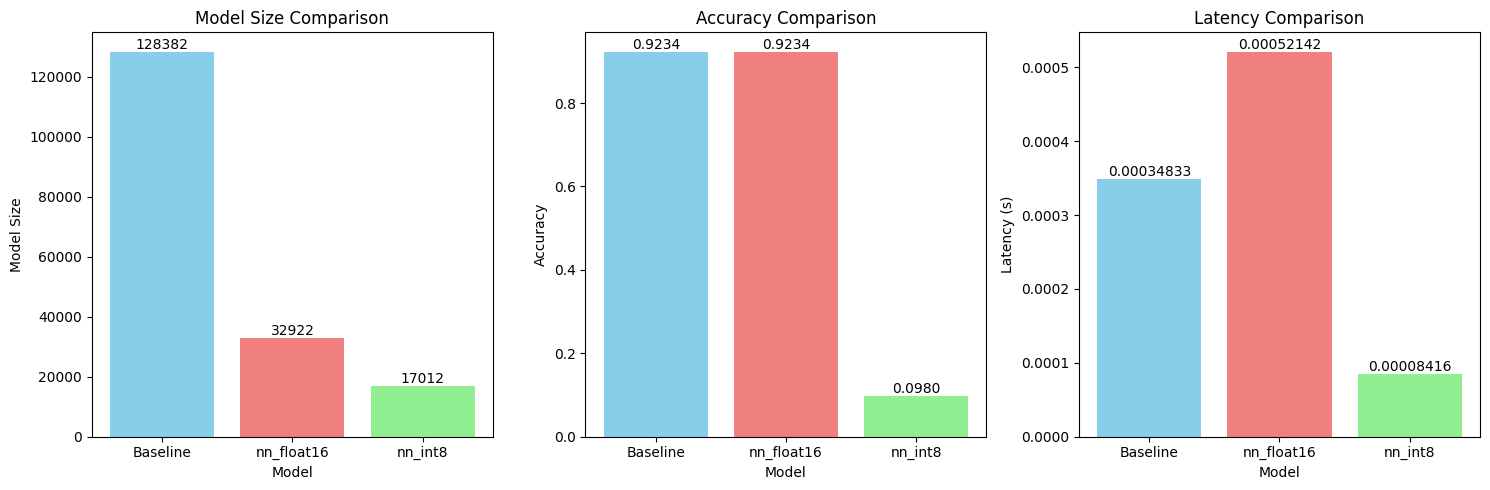

In [ ]:
import matplotlib.pyplot as plt
import os

# Sample data
models = ['Baseline', 'nn_float16', 'nn_int8']
model_sizes = [os.path.getsize('weights.bin'), os.path.getsize('weights_float16.bin'), os.path.getsize('weights_int8.bin')]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot model size
axes[0].bar(models, model_sizes, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Model Size')
axes[0].set_title('Model Size Comparison')
for i, v in enumerate(model_sizes):
    axes[0].text(i, v, str(v), ha='center', va='bottom')


# Plot accuracies
axes[1].bar(models, accuracies, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Comparison')
for i, v in enumerate(accuracies):
    axes[1].text(i, v, f'{v:.4f}', ha='center', va='bottom')


# Plot latency
axes[2].bar(models, times_forward_pass, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[2].set_xlabel('Model')
axes[2].set_ylabel('Latency (s)')
axes[2].set_title('Latency Comparison')
for i, v in enumerate(times_forward_pass):
    axes[2].text(i, v, f'{v:.8f}', ha='center', va='bottom')

# Adjust layout
plt.tight_layout()
plt.show()

### Range tuning and centering
For quantization to be effective, you should smartly choose the range of numbers you will code with the fewer bits available after quantization. To do so, you should evaluate the dynamic ranges of the variables to be quantized and map the values using that as the full range.

Make a histogram plot of the model weights in order to verify their range. Then write a function to quantize the weights stored in the exported binary file to INT8 and store the resulting weights in another file. Finally, run again the INT8 quantized inference with the newly computed weights and compare with the previous versions using the same metrics.

In [ ]:
def plot_histogram(weights):
  plt.figure(figsize=(10, 5))
  plt.plot(1, 2, 1)
  plt.hist(weights, bins=50)  # Adjust bins as needed
  plt.xlabel('Weight Value')
  plt.ylabel('Frequency')
  plt.title('Weights')

  plt.tight_layout()
  plt.show()

def quantize_INT8(weights):
  weights_int8 = np.int8(np.array(weights) * scale + zero_point)
  return weights_int8

In [ ]:
def save_weights(weights_file, weights):
  with open(weights_file, 'wb') as f:
      np.savez(f, weights_input_hidden =  weights['weights_input_hidden'],
                  bias_input_hidden =     weights['bias_input_hidden'],
                  weights_hidden_output = weights['weights_hidden_output'],
                  bias_hidden_output =    weights['bias_hidden_output']
      )

def load_weights(weights_file):
  weights = {}
  with open(weights_file, 'rb') as f:
      data = np.load(f)
      weights['weights_input_hidden'] = data['weights_input_hidden']
      weights['bias_input_hidden'] = data['bias_input_hidden']
      weights['weights_hidden_output'] = data['weights_hidden_output']
      weights['bias_hidden_output'] = data['bias_hidden_output']
  return weights

In [ ]:
def get_weights(format_weights):
  weights = []
  weights.extend(format_weights['weights_input_hidden'].flatten())
  weights.extend(format_weights['bias_input_hidden'].flatten())
  weights.extend(format_weights['weights_hidden_output'].flatten())
  weights.extend(format_weights['bias_hidden_output'].flatten())
  return weights

def clip_model(format_weights):
  # set to zero the smallest weights, according to the given percentage
  threshold = 2
  for layer,weight_layer in format_weights.items():
    # Clip weights directly within the weight layer array
    format_weights[layer] = np.clip(weight_layer, -threshold, threshold)
  return format_weights

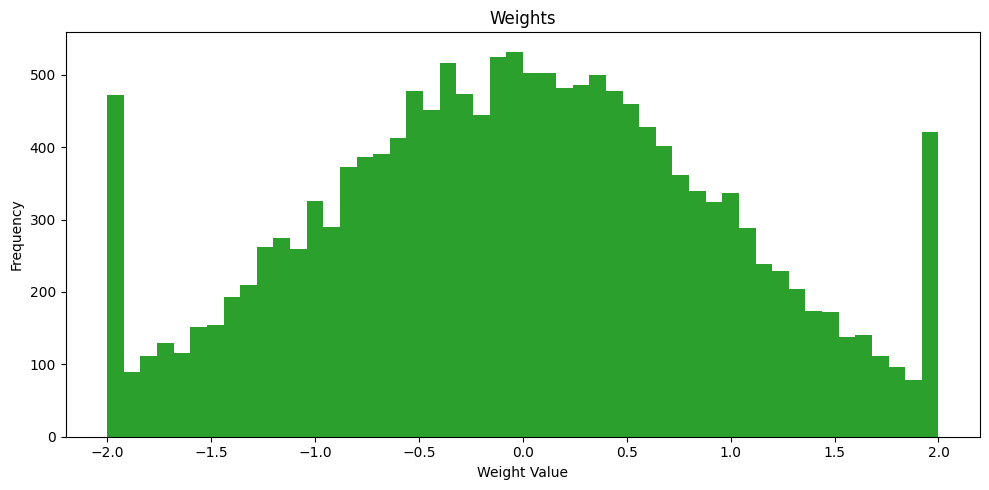

In [ ]:
import matplotlib.pyplot as plt
format_weights = load_weights('weights.bin')
format_weights = clip_model(format_weights)
weights = get_weights(format_weights)

# Calculate quantization parameters
max_weight = np.max(weights)
min_weight = np.min(weights)
scale =  255 / (max_weight - min_weight) # 256 levels in int8 (0-255)
zero_point = -round(scale * min_weight) - 128

plot_histogram(weights)

quantize_weigths = quantize_INT8(weights)
format_weights['weights_input_hidden'] =  quantize_INT8(format_weights['weights_input_hidden'])
format_weights['bias_input_hidden'] =     quantize_INT8(format_weights['bias_input_hidden'])
format_weights['weights_hidden_output'] = quantize_INT8(format_weights['weights_hidden_output'])
format_weights['bias_hidden_output'] =    quantize_INT8(format_weights['bias_hidden_output'])

In [ ]:
save_weights('quantized_weights.bin', format_weights)

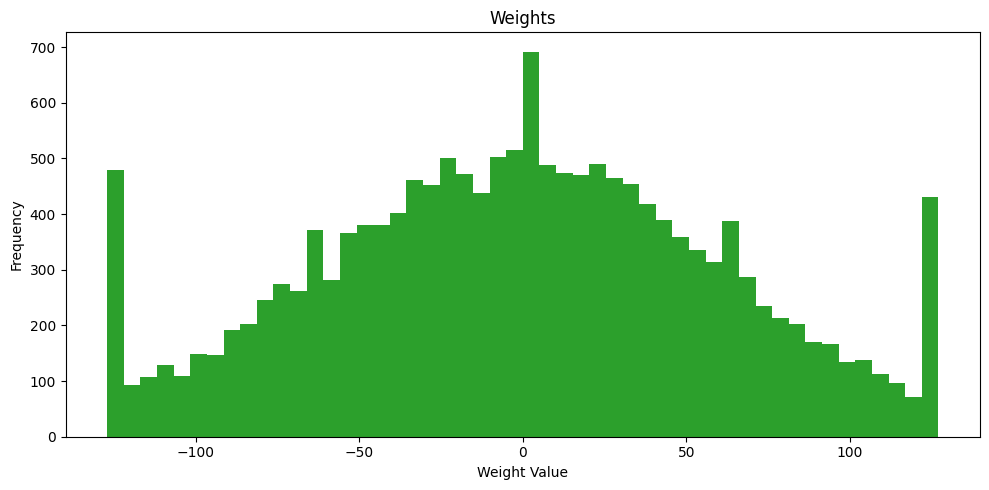

In [ ]:
weights_proof = load_weights(SAVE_QUANTIZED_WEIGHTS_FILE)
weights_proof = get_weights(weights_proof)
plot_histogram(weights_proof)

In [ ]:
# Load the quantized weights and create a new model
nn_int8_quantized = NeuralNetwork(input_size=784, hidden_size = 20, output_size=10)
nn_int8_quantized.load_weights_binary(SAVE_QUANTIZED_WEIGHTS_FILE)
quantized_accuracy = nn_int8_quantized.test_data(test_images,quantization = None)


Test the trained model:
Forward pass time: 0.00044655799865722656 seconds


<ipython-input-42-c44d5c76b4dd>:25: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


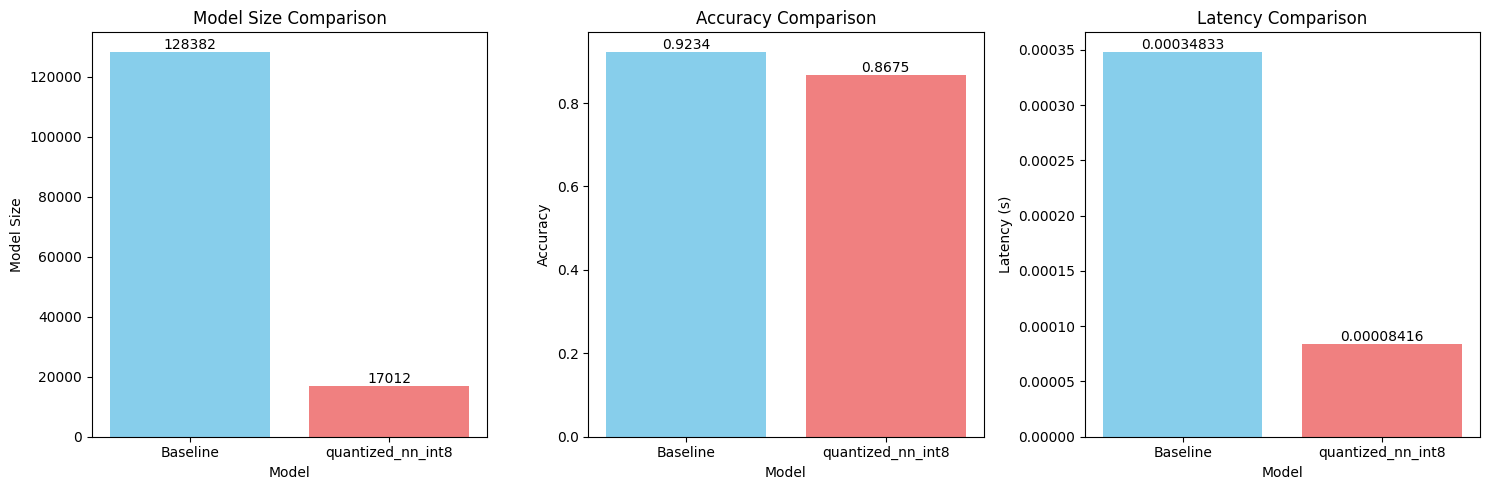

In [ ]:
import matplotlib.pyplot as plt
import os

accuracies = accuracies[0], quantized_accuracy
times_forward_pass = times_forward_pass[0], times_forward_pass[-2]

# Sample data
models = ['Baseline', 'quantized_nn_int8']
model_sizes = [os.path.getsize('weights.bin'), os.path.getsize('quantized_weights.bin')]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot model size
axes[0].bar(models, model_sizes, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Model Size')
axes[0].set_title('Model Size Comparison')
for i, v in enumerate(model_sizes):
    axes[0].text(i, v, str(v), ha='center', va='bottom')


# Plot accuracies
axes[1].bar(models, accuracies, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Comparison')
for i, v in enumerate(accuracies):
    axes[1].text(i, v, f'{v:.4f}', ha='center', va='bottom')


# Plot latency
axes[2].bar(models, times_forward_pass, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[2].set_xlabel('Model')
axes[2].set_ylabel('Latency (s)')
axes[2].set_title('Latency Comparison')
for i, v in enumerate(times_forward_pass):
    axes[2].text(i, v, f'{v:.8f}', ha='center', va='bottom')

# Adjust layout
plt.tight_layout()
plt.show()

### Pruning
Besides reducing precision for the network weights, we can also decide to eliminate network connections that do not contribute significantly to the model. This can be achieved by simply removing the connections whose weights are closest to zero.

In this part of the lab you are asked to generate three pruned versions of the original model by setting to zero some of the weights:


*   Set to zero the smallest 10% of weights
*   Set to zero the smallest 30% of weights
*   Set to zero the smallest 50% of weights

Report the accuracy for each model against the estimated memory savings.



In [ ]:
format_weights = load_weights(SAVE_WEIGHTS_FILE)
weights = get_weights(format_weights)

In [ ]:
def prune_model(weights,format_weights, percentage):
  # set to zero the smallest weights, according to the given percentage
  weights_sorted = np.sort(np.abs(weights))
  percent_size = int(len(weights)*percentage)
  threshold = weights_sorted[percent_size]
  for layer, weights_layers in format_weights.items():
    weights_layers[np.abs(weights_layers) < threshold] = 0  # Prune weights below threshold

  return format_weights

In [ ]:
weights_pruned_10_percent = prune_model(weights,format_weights,0.1)

In [ ]:
save_weights('weights_pruned_10_percent.bin', weights_pruned_10_percent)

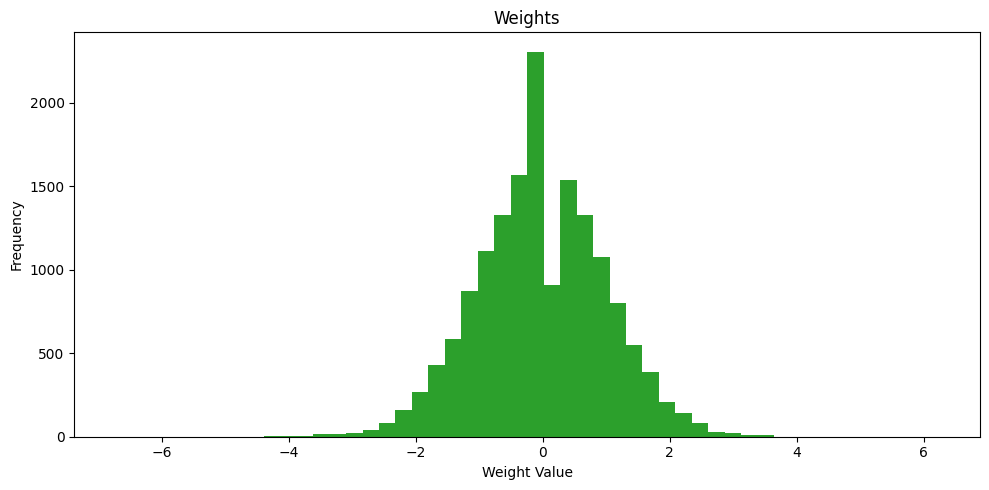

In [ ]:
weights_proof = load_weights('weights_pruned_10_percent.bin')
weights_proof = get_weights(weights_proof)
plot_histogram(weights_proof)

In [ ]:
# Load the quantized weights and create a new model
nn_weights_pruned_10_percent = NeuralNetwork(input_size=784, hidden_size = 20, output_size=10)
nn_weights_pruned_10_percent.load_weights_binary('weights_pruned_10_percent.bin')
nn_weights_pruned_10_percent.test_data(test_images,quantization = None)


Test the trained model:
Forward pass time: 0.00010037422180175781 seconds


0.9243

In [ ]:
weights_pruned_30_percent = prune_model(weights,format_weights,0.3)

In [ ]:
save_weights('weights_pruned_30_percent.bin', weights_pruned_30_percent)

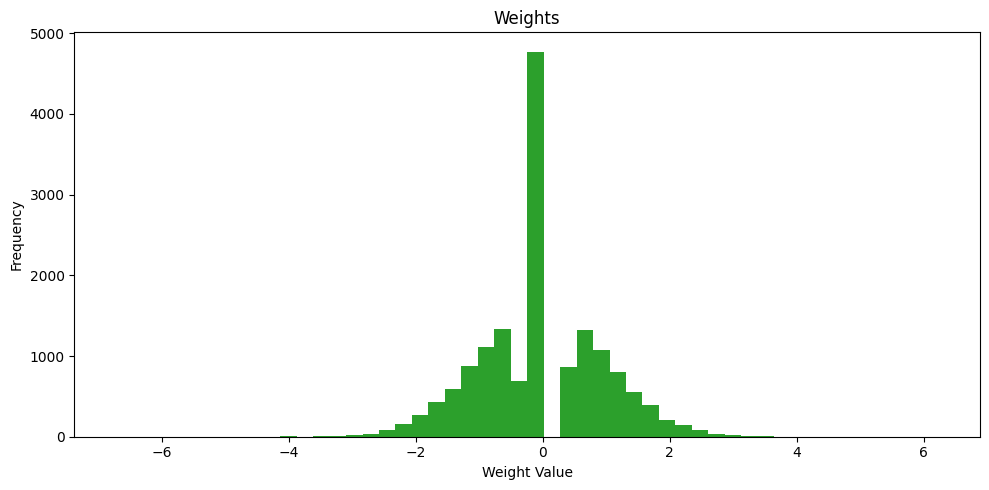

In [ ]:
weights_proof = load_weights('weights_pruned_30_percent.bin')
weights_proof = get_weights(weights_proof)
plot_histogram(weights_proof)

In [ ]:
# Load the quantized weights and create a new model
nn_weights_pruned_30_percent = NeuralNetwork(input_size=784, hidden_size = 20, output_size=10)
nn_weights_pruned_30_percent.load_weights_binary('weights_pruned_30_percent.bin')
nn_weights_pruned_30_percent.test_data(test_images,quantization = None)


Test the trained model:
Forward pass time: 0.00010085105895996094 seconds


0.9174

In [ ]:
weights_pruned_50_percent = prune_model(weights,format_weights,0.5)

In [ ]:
save_weights('weights_pruned_50_percent.bin', weights_pruned_50_percent)

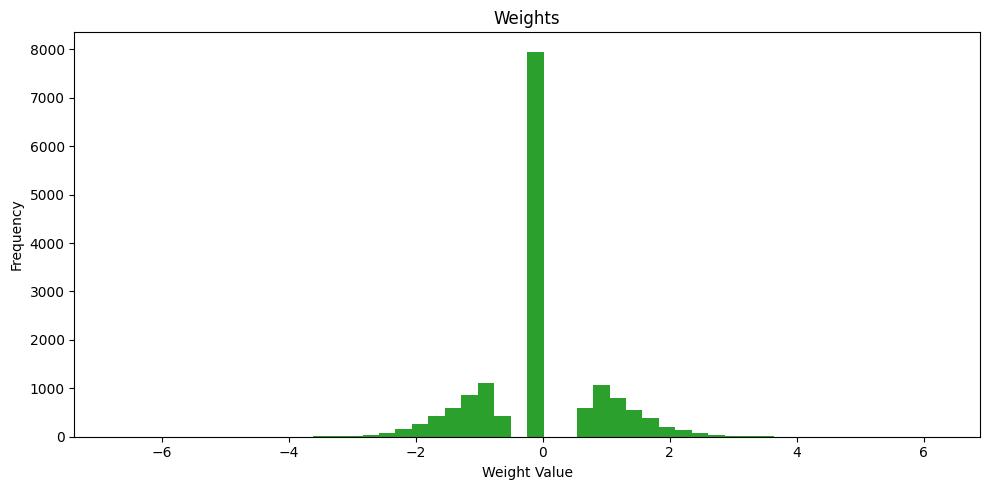

In [ ]:
weights_proof = load_weights('weights_pruned_50_percent.bin')
weights_proof = get_weights(weights_proof)
plot_histogram(weights_proof)

In [ ]:
# Load the quantized weights and create a new model
nn_weights_pruned_50_percent = NeuralNetwork(input_size=784, hidden_size = 20, output_size=10)
nn_weights_pruned_50_percent.load_weights_binary('weights_pruned_50_percent.bin')
nn_weights_pruned_50_percent.test_data(test_images,quantization = None)


Test the trained model:
Forward pass time: 0.00030875205993652344 seconds


0.9008

In [ ]:
def remove_zeros_from_array(weights):
  new_weight = []
  for weight in np.nditer(weights):  # Use nditer to iterate over each element
    if weight:  # Checks if the individual weight is non-zero
      new_weight.append(weight.item())  # Use .item() to get the scalar value
  return new_weight

In [ ]:
weights_10_percent_without_zeros = load_weights('weights_pruned_10_percent.bin')
for key in weights_10_percent_without_zeros:
  weights_10_percent_without_zeros[key] = remove_zeros_from_array(weights_10_percent_without_zeros[key])
save_weights('weights_10_percent_without_zeros.bin', weights_10_percent_without_zeros)

In [ ]:
weights_30_percent_without_zeros = load_weights('weights_pruned_30_percent.bin')
for key in weights_30_percent_without_zeros:
  weights_30_percent_without_zeros[key] = remove_zeros_from_array(weights_30_percent_without_zeros[key])
save_weights('weights_30_percent_without_zeros.bin', weights_30_percent_without_zeros)

In [ ]:
weights_50_percent_without_zeros = load_weights('weights_pruned_50_percent.bin')
for key in weights_50_percent_without_zeros:
  weights_50_percent_without_zeros[key] = remove_zeros_from_array(weights_50_percent_without_zeros[key])
save_weights('weights_50_percent_without_zeros.bin', weights_50_percent_without_zeros)


Test the trained model:
Forward pass time: 0.00010013580322265625 seconds

Test the trained model:
Forward pass time: 5.793571472167969e-05 seconds

Test the trained model:
Forward pass time: 0.0003466606140136719 seconds


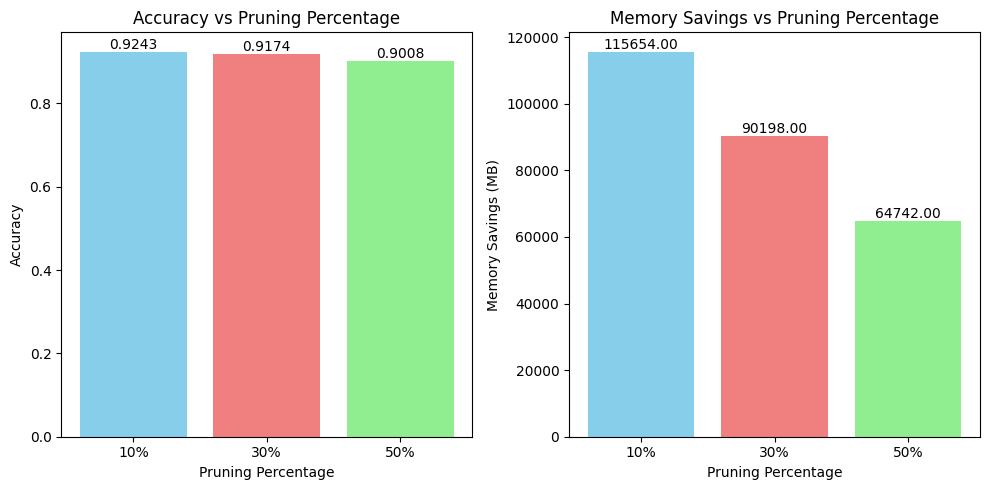

In [ ]:
# prompt: Report the accuracy for each model against the estimated memory savings

import matplotlib.pyplot as plt
import os

# Sample data (replace with your actual data)
models = ['10%', '30%', '50%']
accuracies = [nn_weights_pruned_10_percent.test_data(test_images,quantization = None),
              nn_weights_pruned_30_percent.test_data(test_images,quantization = None),
              nn_weights_pruned_50_percent.test_data(test_images,quantization = None)]
model_sizes = [os.path.getsize('weights_10_percent_without_zeros.bin'),
               os.path.getsize('weights_30_percent_without_zeros.bin'),
               os.path.getsize('weights_50_percent_without_zeros.bin')]

# Memory savings calculation (example - replace with your calculation)
original_size = os.path.getsize('weights.bin')

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot accuracy vs memory savings
axes[0].bar(models, accuracies, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0].set_xlabel('Pruning Percentage')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Pruning Percentage')
for i, v in enumerate(accuracies):
    axes[0].text(i, v, f'{v:.4f}', ha='center', va='bottom')


axes[1].bar(models, model_sizes, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[1].set_xlabel('Pruning Percentage')
axes[1].set_ylabel('Memory Savings (MB)')
axes[1].set_title('Memory Savings vs Pruning Percentage')
for i, v in enumerate(model_sizes):
    axes[1].text(i, v, f'{v:.2f}', ha='center', va='bottom')

# Adjust layout
plt.tight_layout()
plt.show()

## Analysis

Discuss the following questions based on the lab experiments and the theory studied:


*   What are the advantages an disadvantages of storing model weights in different formats?

Advantages:

If we use formats like FP16 or INT8 we can significantly reduces the storage space required compared to storage default (FP32 or FP64).

Lower-precision formats can achieve faster inference times because they require simpler computations.

Disadvantages:

Using lower-precision formats can lost important accuracy, because they have less information.

It's important to be careful with model training and how We lose information. We can lose useful information that We need to have a good model.

*   How much reduction in model memory requirements can be achieved by each of the versions obtained?

FP16 Quantization: Reduces model size by approximately 50% compared to FP32. This is because FP16 uses half the number of bits to represent each weight value.

INT8 Quantization: Reduces model size by approximately 75% compared to FP32. INT8 uses only 8 bits.

Pruning: In the lab experiments, pruning 10%, 30%, and 50% of the weights resulted in approximately 10%, 30%, and 50% reduction in model size, respectively.

*   What are the posible computational advantages of the obtained models and how do they depend on the hardware?

On modern GPUs and specialized hardware accelerators,lower-precision formats like FP16 and INT8 can achive to significant speedups during inference.

On older CPUs or embedded devices that lack optimized support for low-precision formats, the performance benefits might be less pronounced or even nonexistent.

